# Self-Driving Car Engineer Nanodegree


## Project: **Finding Lane Lines on the Road** 


## Import Packages

In [2]:
#importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
%matplotlib inline

## Helper Functions

Below are some helper functions to help get you started. They should look familiar from the lesson!

In [3]:
import math

def grayscale(img):
    """Applies the Grayscale transform
    This will return an image with only one color channel
    but NOTE: to see the returned image as grayscale
    (assuming your grayscaled image is called 'gray')
    you should call plt.imshow(gray, cmap='gray')"""
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Or use BGR2GRAY if you read an image with cv2.imread()
    # return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
def canny(img, low_threshold, high_threshold):
    """Applies the Canny transform"""
    return cv2.Canny(img, low_threshold, high_threshold)

def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def region_of_interest(img, vertices):
    """
    Applies an image mask.
    
    Only keeps the region of the image defined by the polygon
    formed from `vertices`. The rest of the image is set to black.
    """
    #defining a blank mask to start with
    mask = np.zeros_like(img)   
    
    #defining a 3 channel or 1 channel color to fill the mask with depending on the input image
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # i.e. 3 or 4 depending on your image
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
        
    #filling pixels inside the polygon defined by "vertices" with the fill color    
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    
    #returning the image only where mask pixels are nonzero
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image


def draw_lines(img, lines, color=[255, 0, 0], thickness=2):
    """
    Think about things like separating line segments by their 
    slope ((y2-y1)/(x2-x1)) to decide which segments are part of the left
    line vs. the right line.  Then, you can average the position of each of 
    the lines and extrapolate to the top and bottom of the lane.
    
    This function draws `lines` with `color` and `thickness`.    
    Lines are drawn on the image inplace (mutates the image).
    If you want to make the lines semi-transparent, think about combining
    this function with the weighted_img() function below
    """
    for line in lines:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), color, thickness)

def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """
    `img` should be the output of a Canny transform.
        
    Returns an image with hough lines drawn.
    """
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return (lines, line_img)

# Python 3 has support for cool math symbols.

def weighted_img(img, initial_img, α=0.8, β=1., γ=0.):
    """
    `img` is the output of the hough_lines(), An image with lines drawn on it.
    Should be a blank image (all black) with lines drawn on it.
    
    `initial_img` should be the image before any processing.
    
    The result image is computed as follows:
    
    initial_img * α + img * β + γ
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, α, img, β, γ)

## Test Images

Build your pipeline to work on the images in the directory "test_images"  
**You should make sure your pipeline works well on these images before you try the videos.**

In [4]:
import os
all_test_files = [ 'test_images/{}'.format(filename) for filename in os.listdir("test_images/") ]

## Build a Lane Finding Pipeline



Build the pipeline and run your solution on all test_images. Make copies into the `test_images_output` directory, and you can use the images in your writeup report.

Try tuning the various parameters, especially the low and high Canny thresholds as well as the Hough lines parameters.

In [5]:
# Some special functions

def getMaskVerticesLeft( image_shape ):
    image_height, image_width, _ = image_shape
    vertices= [
        (.00*image_width, 1.0*image_height),
        (.00*image_width, .00*image_height),
        (.50*image_width, .00*image_height),
        (.50*image_width, 1.0*image_height)
    ]
    return np.array( [vertices], dtype=np.int32 )

def getMaskVerticesRight( image_shape ):
    image_height, image_width, _ = image_shape
    vertices= [
        (1.0*image_width, 1.0*image_height),
        (1.0*image_width, .00*image_height),
        (.50*image_width, .00*image_height),
        (.50*image_width, 1.0*image_height)
    ]
    return np.array( [vertices], dtype=np.int32 )

def lineLength( x1, y1, x2, y2 ):
    x_distance = ( x1 - x2 ) ** 2
    y_distance = ( y1 - y2 ) ** 2
    return ( x_distance + y_distance ) ** 0.5

def lineSlope( x1, y1, x2, y2 ):
    numerator = y2 - y1
    denominator = x2 - x1
    if denominator == 0:
        return math.inf
    return numerator / denominator

def lineInfo( x1, y1, x2, y2 ):
    length = lineLength( x1, y1, x2, y2 )
    slope = lineSlope( x1, y1, x2, y2 )
    print( '({},{}) --> ({},{}) len={} m={}'.format( x1, y1, x2, y2, length, slope) )
    
def accumulateLinePoints( lines ):
    all_x = []
    all_y = []
    for line_cluster in lines:
        for line in line_cluster:
            l = line.tolist()
            all_x += l[::2] # slice out the x values
            all_y += l[1::2] # slice out the y values
            #lineInfo( *line ) #debugging info
    return (all_x,all_y)

def extrapolateLines( lines, image_shape, left=True ):
    # Going to use linear regression to average out the line points
    # we need to separate out the x and y points
    all_x, all_y = accumulateLinePoints( lines )
    
    # Calculate the intercepts on the linear regression
    p = np.polyfit( all_x, all_y, 1 )
    
    # Construct the start and endpoints of the averaged line
    # Params depend on left or right side of image
    start_x = 0 if left else image_shape[1]
    start_y = int( np.polyval(p, start_x) )

    end_x = int( image_shape[1] * ( .48 if left else .54 ) )
    end_y = int( np.polyval(p, end_x) )
    
    # This represents our averaged line
    average_line = [ start_x, start_y, end_x, end_y ]
    return average_line


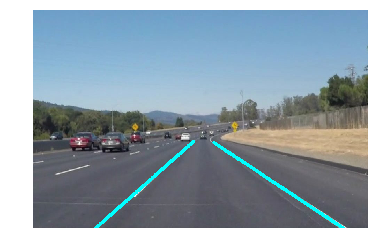

In [26]:
# Define some parameters to some function calls
# below, to clean up the flow of the script

params_hough = {
    'rho': 1,
    'theta': np.pi/180,
    'threshold': 15,
    'min_line_len': 40,
    'max_line_gap': 20
}

params_canny = {
    'low_threshold': 50,
    'high_threshold': 150
}

params_blur = {
    'kernel_size': 5
}

def getMaskVertices( image_shape ):
    image_height, image_width, _ = image_shape
    vertices= [
        (.06*image_width, 1.0*image_height),
        (.48*image_width, .59*image_height),
        (.54*image_width, .59*image_height),
        (.95*image_width, 1.0*image_height)
    ]
    return np.array( [vertices], dtype=np.int32 )

def drawMask( image, vertices ):
    reference_image = np.copy( image )
    cv2.polylines( reference_image, vertices, True, 255, 4 )
    return reference_image

def showImage( image, gray=False ):
    plt.axis('off')
    plt.imshow( image, aspect='auto', cmap=( 'gray' if gray else None ) )
    plt.show()

def detectLaneLines( filename, index ):
    image_original = mpimg.imread( filename )
    image_gray = grayscale( image_original )
    image_blurred = gaussian_blur( image_gray, **params_blur )
    image_canny_edges = canny( image_blurred, **params_canny )
    
    mask_vertices = getMaskVertices( image_original.shape )
    image_mask_visible = drawMask( image_original, mask_vertices )
    image_masked = region_of_interest( image_canny_edges, mask_vertices )
    
    ## find and extrapolate lane lines
    image_masked_left = region_of_interest( image_masked, getMaskVerticesLeft( image_original.shape ) )
    lines_left_hough, image_left_lines = hough_lines( image_masked_left, **params_hough )
    lane_line_left = extrapolateLines( lines_left_hough, image_original.shape )
    
    image_masked_right = region_of_interest( image_masked, getMaskVerticesRight( image_original.shape ) )
    image_mask_right = drawMask( image_original, getMaskVerticesRight( image_original.shape ) )
    lines_right_hough, image_right_lines = hough_lines( image_masked_right, **params_hough )
    lane_line_right = extrapolateLines( lines_right_hough, image_original.shape, left=False )
   
    image_lines_extrapolated = np.copy( image_original )
    draw_lines( image_lines_extrapolated, [[lane_line_left],[lane_line_right]], thickness=8, color=[0, 255, 255] )

    ## Non-extrapolated lines
    lines_hough, image_lines_hough = hough_lines( image_masked, **params_hough )
    image_lines_overlayed = weighted_img( image_lines_hough, image_original )
    
#     showImage(image_original)
#     showImage(image_gray, True)
#     showImage(image_blurred, True)
#     showImage(image_canny_edges, True)
#     showImage(image_mask_visible)
#     showImage(image_mask_right)
#     showImage(image_right_lines)
    showImage(image_lines_extrapolated)
    
for index, filename in enumerate(all_test_files):
    detectLaneLines( filename, index )
    break


## Test on Videos

In [7]:
# Import everything needed to edit/save/watch video clips
from moviepy.editor import VideoFileClip
from IPython.display import HTML

In [8]:
def process_image( image_original ):
    image_gray = grayscale( image_original )
    image_blurred = gaussian_blur( image_gray, **params_blur )
    image_canny_edges = canny( image_blurred, **params_canny )
    
    mask_vertices = getMaskVertices( image_original.shape )
    image_mask_visible = drawMask( image_original, mask_vertices )
    image_masked = region_of_interest( image_canny_edges, mask_vertices )
    
    ## find and extrapolate lane lines
    image_masked_left = region_of_interest( image_masked, getMaskVerticesLeft( image_original.shape ) )
    lines_left_hough, image_left_lines = hough_lines( image_masked_left, **params_hough )
    lane_line_left = extrapolateLines( lines_left_hough, image_original.shape )
    
    image_masked_right = region_of_interest( image_masked, getMaskVerticesRight( image_original.shape ) )
    image_mask_right = drawMask( image_original, getMaskVerticesRight( image_original.shape ) )
    lines_right_hough, image_right_lines = hough_lines( image_masked_right, **params_hough )
    lane_line_right = extrapolateLines( lines_right_hough, image_original.shape, left=False )
   
    image_lines_extrapolated = np.copy( image_original )
    draw_lines( image_lines_extrapolated, [[lane_line_left],[lane_line_right]], thickness=8, color=[0, 255, 255] )

    return image_lines_extrapolated

Let's try the one with the solid white lane on the right first ...

In [9]:
if not os.path.exists('test_videos_output'):
   os.mkdir('test_videos_output')

white_output = 'test_videos_output/solidWhiteRight.mp4'

# clip1 = VideoFileClip("test_videos/solidWhiteRight.mp4").subclip(0,5)
clip1 = VideoFileClip("test_videos/solidWhiteRight.mp4")
white_clip = clip1.fl_image(process_image)
%time white_clip.write_videofile(white_output, audio=False)

[MoviePy] >>>> Building video test_videos_output/solidWhiteRight.mp4
[MoviePy] Writing video test_videos_output/solidWhiteRight.mp4


100%|█████████▉| 221/222 [00:06<00:00, 32.37it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: test_videos_output/solidWhiteRight.mp4 

CPU times: user 3.59 s, sys: 1.18 s, total: 4.77 s
Wall time: 7.27 s


Play the video inline, or if you prefer find the video in your filesystem (should be in the same directory) and play it in your video player of choice.

In [10]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(white_output))

## Improve the draw_lines() function

**At this point, if you were successful with making the pipeline and tuning parameters, you probably have the Hough line segments drawn onto the road, but what about identifying the full extent of the lane and marking it clearly as in the example video (P1_example.mp4)?  Think about defining a line to run the full length of the visible lane based on the line segments you identified with the Hough Transform. As mentioned previously, try to average and/or extrapolate the line segments you've detected to map out the full extent of the lane lines. You can see an example of the result you're going for in the video "P1_example.mp4".**

**Go back and modify your draw_lines function accordingly and try re-running your pipeline. The new output should draw a single, solid line over the left lane line and a single, solid line over the right lane line. The lines should start from the bottom of the image and extend out to the top of the region of interest.**

Now for the one with the solid yellow lane on the left. This one's more tricky!

In [11]:
yellow_output = 'test_videos_output/solidYellowLeft.mp4'
# clip2 = VideoFileClip('test_videos/solidYellowLeft.mp4').subclip(0,5)
clip2 = VideoFileClip('test_videos/solidYellowLeft.mp4')
yellow_clip = clip2.fl_image(process_image)
%time yellow_clip.write_videofile(yellow_output, audio=False)

[MoviePy] >>>> Building video test_videos_output/solidYellowLeft.mp4
[MoviePy] Writing video test_videos_output/solidYellowLeft.mp4


100%|█████████▉| 681/682 [00:24<00:00, 27.55it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: test_videos_output/solidYellowLeft.mp4 

CPU times: user 12.2 s, sys: 4.04 s, total: 16.3 s
Wall time: 25.7 s


In [12]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(yellow_output))

## Writeup and Submission

If you're satisfied with your video outputs, it's time to make the report writeup in a pdf or markdown file. Once you have this Ipython notebook ready along with the writeup, it's time to submit for review! Here is a [link](https://github.com/udacity/CarND-LaneLines-P1/blob/master/writeup_template.md) to the writeup template file.


## Optional Challenge

Try your lane finding pipeline on the video below.  Does it still work?  Can you figure out a way to make it more robust?  If you're up for the challenge, modify your pipeline so it works with this video and submit it along with the rest of your project!

In [13]:
challenge_output = 'test_videos_output/challenge.mp4'

#clip3 = VideoFileClip('test_videos/challenge.mp4').subclip(0,5)
clip3 = VideoFileClip('test_videos/challenge.mp4')
challenge_clip = clip3.fl_image(process_image)
%time challenge_clip.write_videofile(challenge_output, audio=False)

[MoviePy] >>>> Building video test_videos_output/challenge.mp4
[MoviePy] Writing video test_videos_output/challenge.mp4


100%|██████████| 251/251 [00:22<00:00, 13.17it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: test_videos_output/challenge.mp4 

CPU times: user 9.33 s, sys: 3.81 s, total: 13.1 s
Wall time: 24.8 s


In [14]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(challenge_output))